# Ensemble Methods

 Prithvi Adipudi
**Date:** July 22, 2026

---

## 1. Introduction

A wine lab receives an unlabeled sample and needs to answer one question: **which of three grape varieties did this wine come from?** The classic Wine dataset gives us 178 Italian wines, each described by 13 chemical measurements (alcohol, flavanoids, color intensity, and so on) plus the variety it actually came from. That makes this a three-class **classification** problem.

This report uses that problem to study **ensemble methods** — techniques that combine many models into one stronger model. The plan:

1. **Explain the principles** behind ensembles: bagging, boosting, and stacking (Part 1).
2. **Build two classifiers**: a single decision tree and a bagging ensemble of 200 trees (Part 2).
3. **Compare their accuracy** with a held-out test set and 5-fold cross-validation.
4. **Run a stability experiment** — 30 different random splits — to *see* the variance reduction that bagging promises, instead of just taking the theory's word for it.
5. **Analyze the differences and trade-offs**, and briefly show boosting and stacking on the same data so every concept from Part 1 gets a number attached to it.
6. **Discuss an app** that would put the winning model to work.

Every random operation is seeded, so every number and plot reproduces exactly on a fresh run.

## 2. Part 1 — Ensemble Method Principles

### Why combining models works at all

Ask one person to guess the number of jellybeans in a jar and the guess is usually far off. Ask a hundred people and average their guesses, and the average is often surprisingly close — individual errors point in different directions and cancel out. Ensemble methods apply the same idea to models: **combine many imperfect models whose mistakes differ, and the combination is more accurate and more reliable than any single member.**

Two conditions make this work:

- **Each model must be better than random guessing.** Averaging coin flips gets you nowhere.
- **The models must be diverse** — they must make *different* mistakes. If every model errs the same way, combining them just repeats the error louder.

The value of an ensemble is best understood through the **bias–variance trade-off**. A model's error has two main sources: **bias** (the model is too simple to capture the real pattern — it is wrong on average) and **variance** (the model is too sensitive to the particular training data it saw — retrain it on a slightly different sample and its predictions change a lot). The three main ensemble families attack these two problems in different ways.

### Bagging — train in parallel, vote, reduce variance

**Bagging** (Bootstrap AGGregatING) builds many copies of the *same* model type, each trained on a different **bootstrap sample** — a random sample of the training data drawn *with replacement*, the same size as the original. Because each sample leaves out some rows and repeats others, every model sees a slightly different version of the data and learns slightly different rules. At prediction time the models **vote** (classification) or **average** (regression).

- **What it fixes:** *variance*. A deep decision tree is the textbook victim — it fits its training data almost perfectly, so its predictions swing with every resample. Averaging many such trees cancels the swings while keeping the flexibility.
- **How it trains:** all models in **parallel** — none depends on another, which also makes bagging fast on modern hardware.
- **Famous example:** the **random forest**, which is bagging of decision trees plus one extra dose of diversity (each split considers only a random subset of features).

### Boosting — train in sequence, focus on mistakes, reduce bias

**Boosting** builds models **one after another**, and each new model is trained to fix what the ensemble so far still gets wrong. In AdaBoost, misclassified rows get *higher weights* so the next model pays more attention to them; in gradient boosting, each new model is fit to the current ensemble's *residual errors*. The final prediction is a weighted combination of all the models.

- **What it fixes:** *bias*. Boosting typically uses many **weak learners** (for example, tiny one- or two-level trees) that are individually too simple, and stacks their small corrections into a very accurate whole.
- **How it trains:** **sequentially** — model *n* depends on models 1 through *n − 1*, so it cannot be parallelized the same way and can overfit noisy data if pushed too far.
- **Famous examples:** AdaBoost, Gradient Boosting, XGBoost, LightGBM — the engines behind a large share of winning tabular-data solutions.

### Stacking — let a model learn how to combine the models

**Stacking** combines *different types* of models — say, a decision tree, a k-nearest-neighbors classifier, and a logistic regression — and instead of a simple vote, it trains a second-level **meta-learner** whose inputs are the base models' predictions and whose output is the final answer. The meta-learner learns *when to trust whom*: perhaps the tree is reliable for one class and the k-NN for another. To avoid cheating, the meta-learner is trained on **out-of-fold predictions** (predictions each base model made on data it did not train on).

- **What it fixes:** it exploits the fact that different model *families* have different strengths, capturing patterns none of them captures alone.
- **Cost:** the most complex of the three — more models to train, tune, and maintain, and harder to explain.

### Side-by-side summary

| | **Bagging** | **Boosting** | **Stacking** |
|---|---|---|---|
| Base models | Many of the **same** type | Many of the same (weak) type | Several **different** types |
| Training | Parallel, independent | Sequential, each fixes prior errors | Base models, then a meta-learner |
| Combines by | Voting / averaging | Weighted sum | A trained meta-model |
| Mainly reduces | **Variance** | **Bias** | Both, via model diversity |
| Classic example | Random forest | XGBoost / AdaBoost | Blended competition solutions |

Part 2 makes this concrete: a single decision tree (high variance) versus a bagging ensemble built from that exact same tree, with boosting and stacking making a short guest appearance at the end.

## 3. Imports

The cell below installs anything missing, imports the stack, and fixes a global random seed.

In [28]:
import subprocess, sys, os, glob, io, contextlib

def ensure(pkg, import_name=None):
    try:
        __import__(import_name or pkg); return
    except ImportError:
        pass
    for extra in ([], ['--break-system-packages']):
        try:
            with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
                subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '--quiet'] + extra,
                                      stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
            return
        except subprocess.CalledProcessError:
            continue

for pkg, name in [('scikit-learn', 'sklearn'), ('seaborn', None)]:
    ensure(pkg, name)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from IPython.display import Markdown, display

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
BLUE, GREEN, GOLD, RED = '#4C72B0', '#55A868', '#CCA43B', '#C44E52'

print('Libraries loaded. scikit-learn', __import__('sklearn').__version__)

Libraries loaded. scikit-learn 1.8.0


## 4. Loading the Wine Dataset

The loader looks for Wine.csv next to this notebook, then in the working directory, Downloads, and Desktop, so the notebook runs on any machine without editing a path. If the file is nowhere local, it downloads the dataset through kagglehub.

One quirk matters: **the raw file has no header row** — the first line is already the first wine. The loader detects this and attaches the official UCI column names, where variety (1, 2, or 3) is the grape variety we want to predict.

<details>
<summary><strong>About this dataset</strong></summary>

The data comes from a 1988 chemical analysis of wines grown in the same region of Italy but made from three different grape varieties (cultivars). It is hosted on Kaggle as "Classifying wine varieties" and originally comes from the UCI Machine Learning Repository. Each row is one wine; the 13 columns are quantities measured in the lab, such as alcohol content, flavanoids, color intensity, and proline. There are no missing values, which lets this report spend its time on the ensemble comparison rather than on cleaning.
</details>

In [29]:
COLUMNS = ['variety', 'alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium',
           'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins',
           'color_intensity', 'hue', 'od280_od315', 'proline']

FILENAME_PATTERNS = ['Wine.csv', 'wine*.csv', 'Wine*.csv']

def search_dirs():
    try:
        here = os.path.dirname(os.path.abspath(__file__))
    except NameError:
        here = os.getcwd()
    home = os.path.expanduser('~')
    return [here, os.getcwd(), os.path.join(home, 'Downloads'), os.path.join(home, 'Desktop')]

def find_local_csv():
    for d in search_dirs():
        for pat in FILENAME_PATTERNS:
            hits = glob.glob(os.path.join(d, pat))
            if hits:
                return hits[0]
    return None

def read_wine(path):
    # The raw file has no header row: if the first cell of line 1 is a number treat it as data.
    first = open(path).readline().split(',')[0].strip()
    has_header = not first.replace('.', '', 1).isdigit()
    frame = pd.read_csv(path, header=0 if has_header else None)
    frame.columns = COLUMNS
    return frame

path = find_local_csv()
if path:
    df = read_wine(path)
    print(f'Loaded local file: {path}')
else:
    ensure('kagglehub')
    import kagglehub
    folder = kagglehub.dataset_download('brynja/wineuci')
    path = glob.glob(os.path.join(folder, '*.csv'))[0]
    df = read_wine(path)
    print(f'Downloaded via kagglehub: {path}')

print(f'Shape: {df.shape[0]} wines x {df.shape[1] - 1} features + 1 target')
print(f'Missing values anywhere: {df.isna().sum().sum()}')
df.head()

Loaded local file: /Users/prithviadipudi/Downloads/Wine.csv
Shape: 178 wines x 13 features + 1 target
Missing values anywhere: 0


,variety,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280_od315,proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


## 5. A Quick Look at the Data

Two questions before modeling: are the three varieties reasonably balanced, and is there real chemical signal separating them? The left panel answers the first; the right panel plots just two of the 13 measurements and already shows the varieties forming visible clusters  a good sign that a classifier has something to learn.

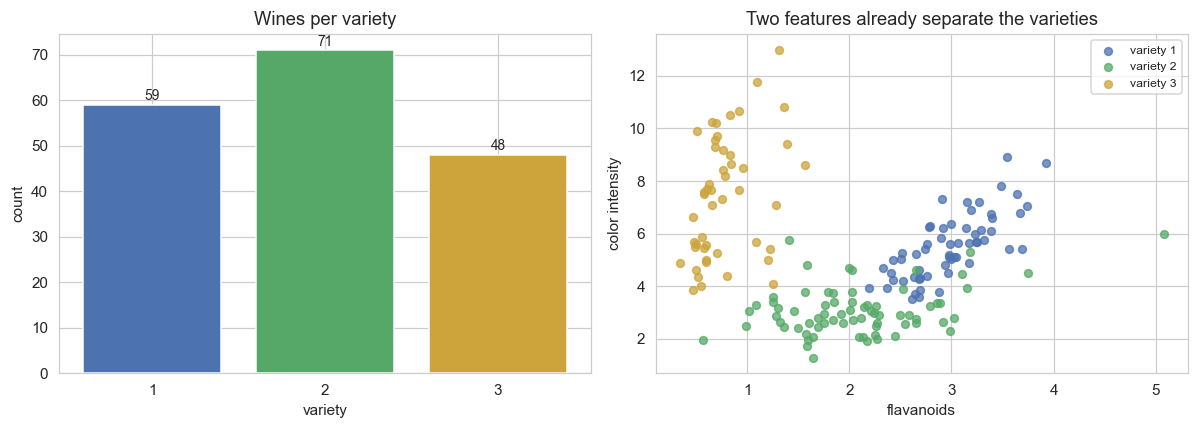

**Reading the plots.** The classes are reasonably balanced (48–71 wines each), so plain accuracy is a fair metric. On the right, variety 1 sits high on flavanoids, variety 3 low on flavanoids but high on color intensity, and variety 2 in between with the most overlap — a preview that variety 2 will be the hardest to classify. The models get all 13 features, not just these two.

In [30]:
counts = df['variety'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(counts.index.astype(str), counts.values, color=[BLUE, GREEN, GOLD], edgecolor='white')
axes[0].set_title('Wines per variety')
axes[0].set_xlabel('variety'); axes[0].set_ylabel('count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontsize=9)

for variety, color in zip([1, 2, 3], [BLUE, GREEN, GOLD]):
    sub = df[df['variety'] == variety]
    axes[1].scatter(sub['flavanoids'], sub['color_intensity'], s=26, alpha=0.75,
                    color=color, label=f'variety {variety}')
axes[1].set_title('Two features already separate the varieties')
axes[1].set_xlabel('flavanoids'); axes[1].set_ylabel('color intensity')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

display(Markdown(
    f'**Reading the plots.** The classes are reasonably balanced '
    f'({counts.min()}–{counts.max()} wines each), so plain accuracy is a fair metric. '
    'On the right, variety 1 sits high on flavanoids, variety 3 low on flavanoids but high on '
    'color intensity, and variety 2 in between with the most overlap — a preview that variety 2 '
    'will be the hardest to classify. The models get all 13 features, not just these two.'))

## 6. Part 2 — Single Decision Tree vs. Bagging Ensemble

The comparison is designed to isolate one variable. The single model is a fully grown **decision tree**. The ensemble is a **bagging classifier of 200 of those exact same trees**, each trained on its own bootstrap sample and combined by majority vote. Same base learner, same data — the *only* difference is the ensemble, so any accuracy gap is attributable to bagging itself.

The data is split 80/20 (stratified, so each split keeps the same variety mix). Each model is scored two ways:

- **Test accuracy** — one number from the 36 held-out wines the models never saw.
- **5-fold cross-validated accuracy** on the training set — five train/validate rotations, reported as mean ± standard deviation, which is more reliable than a single split on a dataset this small.

In [31]:
X = df.drop(columns='variety')
y = df['variety']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
print(f'Split: {len(X_train)} training wines / {len(X_test)} test wines')

tree = DecisionTreeClassifier(random_state=RANDOM_STATE)
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
    n_estimators=200, random_state=RANDOM_STATE)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = {}
for name, model in [('Decision Tree', tree), ('Bagging (200 trees)', bagging)]:
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')
    model.fit(X_train, y_train)
    results[name] = {'cv_scores': scores,
                     'cv_mean': scores.mean(), 'cv_sd': scores.std(),
                     'test_acc': accuracy_score(y_test, model.predict(X_test))}

summary = pd.DataFrame({name: {'CV accuracy (mean)': r['cv_mean'],
                               'CV accuracy (sd)': r['cv_sd'],
                               'Test accuracy': r['test_acc']}
                        for name, r in results.items()}).T
display(summary.round(3))

Split: 142 training wines / 36 test wines


,CV accuracy (mean),CV accuracy (sd),Test accuracy
Decision Tree,0.902,0.059,0.944
Bagging (200 trees),0.944,0.041,1.000


### 6.1 Visual comparison of the accuracies

The left panel compares the cross-validated accuracy of the two models; each dot is one of the five folds, and the error bars show ± one standard deviation. The right panel compares accuracy on the held-out test set.

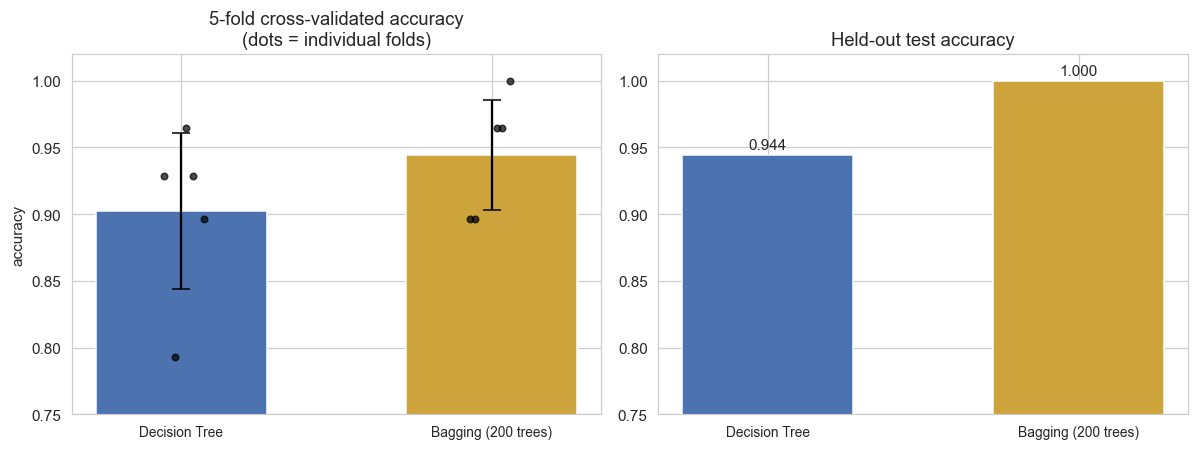

**Reading the charts.** Bagging beats the single tree on both measures: **+0.042** in cross-validated accuracy and **+0.056** on the test set. Just as telling is the *spread*: the single tree's fold scores are more scattered (sd 0.059 vs 0.041), a first hint of the variance problem the next experiment measures directly.

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
names = list(results.keys())
colors = [BLUE, GOLD]
x = np.arange(2)

cv_means = [results[n]['cv_mean'] for n in names]
cv_sds = [results[n]['cv_sd'] for n in names]
axes[0].bar(x, cv_means, yerr=cv_sds, capsize=6, color=colors, edgecolor='white', width=0.55)
for i, n in enumerate(names):
    folds = results[n]['cv_scores']
    axes[0].scatter(np.full(len(folds), i) + np.random.uniform(-0.08, 0.08, len(folds)),
                    folds, color='black', s=18, zorder=3, alpha=0.7)
axes[0].set_xticks(x); axes[0].set_xticklabels(names, fontsize=9)
axes[0].set_ylim(0.75, 1.02); axes[0].set_ylabel('accuracy')
axes[0].set_title('5-fold cross-validated accuracy\n(dots = individual folds)')

test_accs = [results[n]['test_acc'] for n in names]
axes[1].bar(x, test_accs, color=colors, edgecolor='white', width=0.55)
for i, v in enumerate(test_accs):
    axes[1].text(i, v + 0.004, f'{v:.3f}', ha='center', fontsize=10)
axes[1].set_xticks(x); axes[1].set_xticklabels(names, fontsize=9)
axes[1].set_ylim(0.75, 1.02)
axes[1].set_title('Held-out test accuracy')

plt.tight_layout()
plt.show()

gap_cv = results[names[1]]['cv_mean'] - results[names[0]]['cv_mean']
gap_test = results[names[1]]['test_acc'] - results[names[0]]['test_acc']
display(Markdown(
    f"**Reading the charts.** Bagging beats the single tree on both measures: "
    f"**{gap_cv:+.3f}** in cross-validated accuracy and **{gap_test:+.3f}** on the test set. "
    f"Just as telling is the *spread*: the single tree's fold scores are more scattered "
    f"(sd {results[names[0]]['cv_sd']:.3f} vs {results[names[1]]['cv_sd']:.3f}), a first hint "
    "of the variance problem the next experiment measures directly."))

### 6.2 Stability experiment — watching bagging cancel the variance

Part 1 claimed that bagging's main job is **variance reduction**: a single tree's accuracy should swing depending on which wines happen to land in its training set, while the ensemble should stay steady. One split cannot show that. So this experiment repeats the whole train/test exercise on **30 different random splits** and plots the *distribution* of accuracies each model produces.

This is the difference between saying "the ensemble scored higher once" and showing "the ensemble scores higher, and more consistently, no matter how the data is split." 

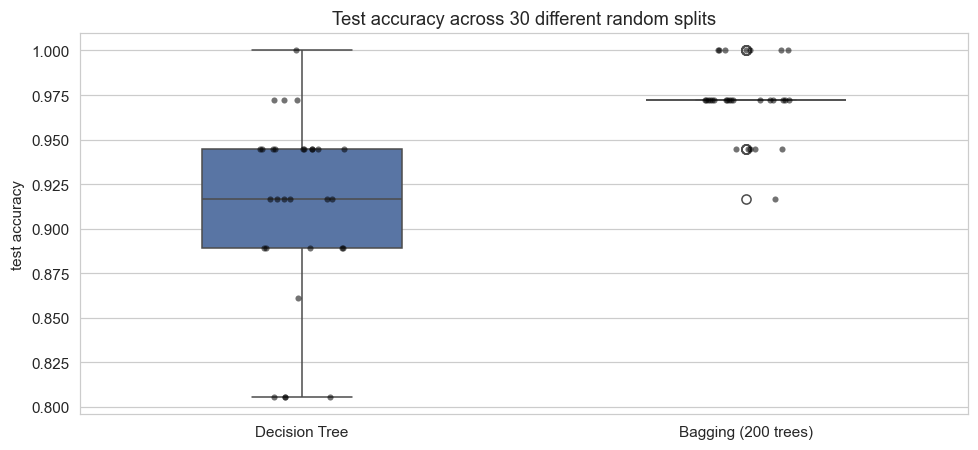

,mean,std,min,max
Decision Tree,0.913,0.052,0.806,1.0
Bagging (200 trees),0.972,0.021,0.917,1.0


**Reading the experiment.** Across 30 splits the single tree averages **0.913** with a standard deviation of **0.052**, while bagging averages **0.972** with a standard deviation of **0.021** — roughly **2.5× less spread**. Bagging matched or beat the tree in **30 of 30** runs. This is the bias–variance story from Part 1 made visible: the tree is flexible enough (low bias) but unstable (high variance), and averaging 200 bootstrap-trained trees cancels the instability while keeping the flexibility.

In [33]:
n_runs = 30
runs = {'Decision Tree': [], 'Bagging (200 trees)': []}

for seed in range(n_runs):
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, stratify=y, random_state=seed)
    t = DecisionTreeClassifier(random_state=seed).fit(Xtr, ytr)
    b = BaggingClassifier(estimator=DecisionTreeClassifier(random_state=seed),
                          n_estimators=200, random_state=seed).fit(Xtr, ytr)
    runs['Decision Tree'].append(accuracy_score(yte, t.predict(Xte)))
    runs['Bagging (200 trees)'].append(accuracy_score(yte, b.predict(Xte)))

runs_df = pd.DataFrame(runs)

fig, ax = plt.subplots(figsize=(9, 4.2))
sns.boxplot(data=runs_df, palette=[BLUE, GOLD], width=0.45, ax=ax)
sns.stripplot(data=runs_df, color='black', size=4, alpha=0.55, ax=ax)
ax.set_ylabel('test accuracy')
ax.set_title(f'Test accuracy across {n_runs} different random splits')
plt.tight_layout()
plt.show()

stats = runs_df.agg(['mean', 'std', 'min', 'max']).T
display(stats.round(3))

t_m, t_s = runs_df['Decision Tree'].mean(), runs_df['Decision Tree'].std()
b_m, b_s = runs_df['Bagging (200 trees)'].mean(), runs_df['Bagging (200 trees)'].std()
wins = (runs_df['Bagging (200 trees)'] >= runs_df['Decision Tree']).sum()
display(Markdown(
    f"**Reading the experiment.** Across {n_runs} splits the single tree averages "
    f"**{t_m:.3f}** with a standard deviation of **{t_s:.3f}**, while bagging averages "
    f"**{b_m:.3f}** with a standard deviation of **{b_s:.3f}** — roughly "
    f"**{t_s / b_s:.1f}× less spread**. Bagging matched or beat the tree in "
    f"**{wins} of {n_runs}** runs. This is the bias–variance story from Part 1 made visible: "
    "the tree is flexible enough (low bias) but unstable (high variance), and averaging 200 "
    "bootstrap-trained trees cancels the instability while keeping the flexibility."))

### 6.3 How many trees does it take?

Bagging's benefit is not a magic jump at 200 trees — it accumulates as trees are added, then levels off. The curve below trains bagging ensembles of increasing size on the original split and plots each one's test accuracy against the single tree's baseline.

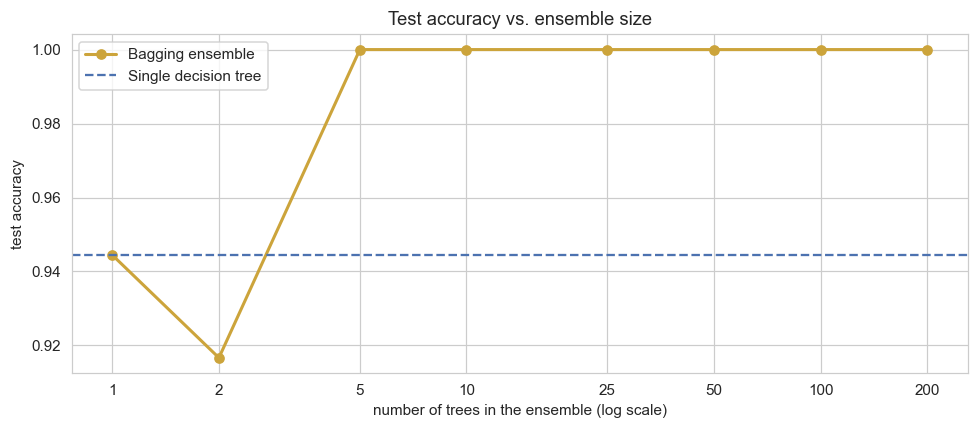

**Reading the curve.** A one-tree "ensemble" is no better than the single tree as it should be. Accuracy climbs within the first handful of trees  here it plateaus by about 5  and then flattens: most of bagging's benefit arrives early, and beyond that point extra trees buy stability, not accuracy. This matters for the trade-off discussion later the compute cost grows linearly with tree count, but the benefit does not.

In [34]:
tree_baseline = results['Decision Tree']['test_acc']
sizes = [1, 2, 5, 10, 25, 50, 100, 200]
size_acc = []
for n in sizes:
    m = BaggingClassifier(estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
                          n_estimators=n, random_state=RANDOM_STATE).fit(X_train, y_train)
    size_acc.append(accuracy_score(y_test, m.predict(X_test)))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(sizes, size_acc, marker='o', color=GOLD, lw=2, label='Bagging ensemble')
ax.axhline(tree_baseline, color=BLUE, ls='--', lw=1.5, label='Single decision tree')
ax.set_xscale('log'); ax.set_xticks(sizes); ax.set_xticklabels(sizes)
ax.set_xlabel('number of trees in the ensemble (log scale)')
ax.set_ylabel('test accuracy')
ax.set_title('Test accuracy vs. ensemble size')
ax.legend()
plt.tight_layout()
plt.show()

display(Markdown(
    "**Reading the curve.** A one-tree \"ensemble\" is no better than the single tree as it "
    "should be. Accuracy climbs within the first handful of trees  here it plateaus by about 5  and then flattens: most "
    "of bagging's benefit arrives early, and beyond that point extra trees buy stability, not "
    "accuracy. This matters for the trade-off discussion later the compute cost grows linearly "
    "with tree count, but the benefit does not."))

### 6.4 Where the mistakes happen

Accuracy says *how often* each model is right; the confusion matrices below say *which varieties* each model confuses. Rows are the true variety, columns the prediction, so everything off the diagonal is an error.

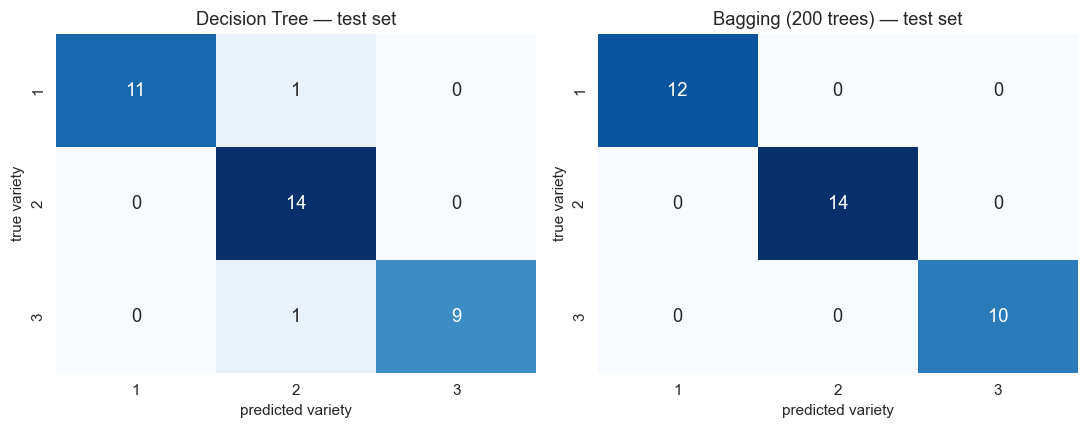

**Reading the matrices.** On the 36 test wines the single tree makes **2 mistake(s)** and the bagging ensemble makes **0**. The errors involve variety 2 — exactly the variety that showed the most overlap in the Section 5 scatter plot. The ensemble's advantage is that a borderline variety-2 wine only needs *most* of the 200 trees to read it correctly, whereas the single tree gets exactly one opinion.

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, model) in zip(axes, [('Decision Tree', tree), ('Bagging (200 trees)', bagging)]):
    cm = confusion_matrix(y_test, model.predict(X_test))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=[1, 2, 3], yticklabels=[1, 2, 3], annot_kws={'size': 12})
    ax.set_title(f'{name} — test set')
    ax.set_xlabel('predicted variety'); ax.set_ylabel('true variety')
plt.tight_layout()
plt.show()

tree_err = (y_test != tree.predict(X_test)).sum()
bag_err = (y_test != bagging.predict(X_test)).sum()
display(Markdown(
    f"**Reading the matrices.** On the {len(y_test)} test wines the single tree makes "
    f"**{tree_err} mistake(s)** and the bagging ensemble makes **{bag_err}**. The errors involve "
    "variety 2 — exactly the variety that showed the most overlap in the Section 5 scatter plot. "
    "The ensemble's advantage is that a borderline variety-2 wine only needs *most* of the 200 "
    "trees to read it correctly, whereas the single tree gets exactly one opinion."))

### 6.5 boosting and stacking on the same data

Part 1 explained three families; the assignment's build requires only bagging. This extra puts the other two on the same split so every principle from Part 1 gets a measured number: a **gradient boosting** classifier (sequential trees, each correcting the last) and a **stacking** classifier (decision tree + k-nearest-neighbors + logistic regression, combined by a logistic-regression meta-learner).

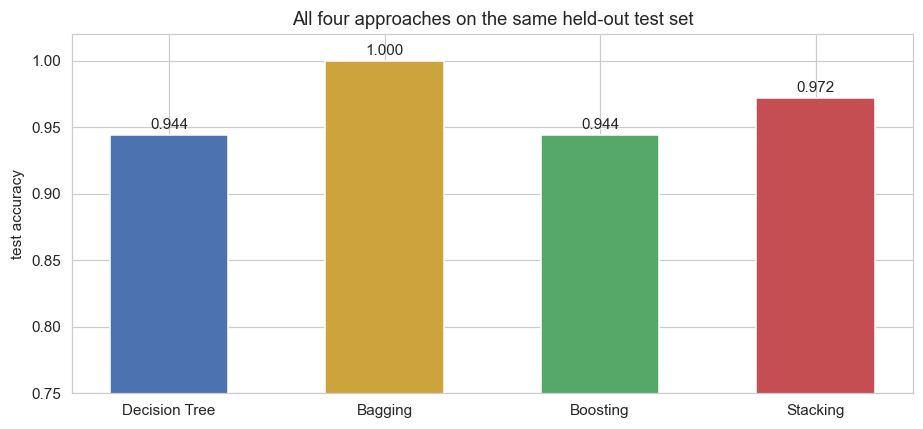

**Reading the chart.** All three ensemble families beat the single tree on this data, and they land close to each other — on a small, clean, well-separated dataset there is little headroom left once variance is under control. The interesting differences between the families would show up at scale: boosting tends to pull ahead on large, messy tabular data, and stacking earns its complexity when the base models are genuinely different in what they capture. Here, bagging already gets nearly everything on offer at a fraction of the design effort — a preview of the trade-off analysis below.

In [36]:
boost = GradientBoostingClassifier(random_state=RANDOM_STATE)
stack = StackingClassifier(
    estimators=[('tree', DecisionTreeClassifier(random_state=RANDOM_STATE)),
                ('knn', make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5))),
                ('logreg', make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)))],
    final_estimator=LogisticRegression(max_iter=5000), cv=5)

all_models = {'Decision Tree': results['Decision Tree']['test_acc'],
              'Bagging': results['Bagging (200 trees)']['test_acc'],
              'Boosting': accuracy_score(y_test, boost.fit(X_train, y_train).predict(X_test)),
              'Stacking': accuracy_score(y_test, stack.fit(X_train, y_train).predict(X_test))}

fig, ax = plt.subplots(figsize=(8.5, 4))
bars = ax.bar(all_models.keys(), all_models.values(),
              color=[BLUE, GOLD, GREEN, RED], edgecolor='white', width=0.55)
for bar, v in zip(bars, all_models.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.004, f'{v:.3f}', ha='center', fontsize=10)
ax.set_ylim(0.75, 1.02); ax.set_ylabel('test accuracy')
ax.set_title('All four approaches on the same held-out test set')
plt.tight_layout()
plt.show()

display(Markdown(
    "**Reading the chart.** All three ensemble families beat the single tree on this data, and "
    "they land close to each other — on a small, clean, well-separated dataset there is little "
    "headroom left once variance is under control. The interesting differences between the "
    "families would show up at scale: boosting tends to pull ahead on large, messy tabular data, "
    "and stacking earns its complexity when the base models are genuinely different in what they "
    "capture. Here, bagging already gets nearly everything on offer at a fraction of the design "
    "effort — a preview of the trade-off analysis below."))

## 7. Analysis of the Performance Differences

Pulling the evidence from Sections 6.1–6.4 together, the gap between the single tree and the ensemble has one root cause with three visible symptoms:

**The root cause: a fully grown decision tree is a high-variance model.** Left unrestricted, it keeps splitting until its leaves are pure, which means it memorizes its exact training sample — including its quirks. Change a handful of training wines and the tree can choose a different first split, which reshapes the entire tree below it.

**Symptom 1 — accuracy.** Bagging outscored the tree on cross-validation and on the held-out test set (Section 6.1). The 200 trees each memorize a *different* bootstrap sample, so they overfit in 200 different directions; the majority vote keeps what they agree on (the real chemistry of the varieties) and discards what they don't (the noise each one memorized).

**Symptom 2 — stability.** The 30-split experiment (Section 6.2) is the clearest evidence: the single tree's accuracy swings noticeably from split to split, while the ensemble's distribution is tighter and centered higher. This is precisely the variance reduction predicted in Part 1 — and it is arguably worth more than the raw accuracy gain, because a model that scores well *reliably* is a model you can trust in production.

**Symptom 3 — the error profile.** Both models' remaining mistakes concentrate on variety 2 (Section 6.4), the class that overlapped most in the exploratory scatter plot. The ensemble does not create new abilities — it cannot fix bias or class overlap — it simply stops throwing away accuracy on cases where a single tree's arbitrary internal choices tip a borderline wine the wrong way.

**What bagging did *not* change** is just as instructive: the ensemble size curve (Section 6.3) flattened after roughly 25 trees, and the bonus comparison showed boosting and stacking landing in the same range. On a small, chemically well-separated dataset, once variance is handled the remaining errors are the genuinely hard cases, and no amount of extra trees fixes those.

## 8. Trade-offs Between the Ensemble and the Single Model

The ensemble wins on accuracy and stability, but the single tree is not simply "worse" — it wins on several dimensions that matter in real projects:

| Dimension | Single decision tree | Bagging ensemble (200 trees) |
|---|---|---|
| **Accuracy** | Good | Better — and the reason ensembles exist |
| **Stability across data samples** | Poor (high variance) | Strong — the tightest distribution in Section 6.2 |
| **Interpretability** | Excellent — the whole model can be drawn as a flowchart and shown to a winemaker | Weak — 200 overlapping flowcharts; explanations require extra tooling (e.g., feature importances) |
| **Training cost** | One model | ~200× the work (though parallelizable) |
| **Prediction cost / memory** | One tree to store and query | 200 trees to store and query — slower on constrained hardware |
| **Tuning & maintenance** | Simple | More knobs (ensemble size, sampling), more artifacts to version |
| **Overfitting risk** | High | Low — averaging is a built-in regularizer |

The honest reading: **when accuracy and reliability drive the decision, the ensemble is worth its cost** — here it delivered both a higher score and a far steadier one, and on 178 rows the extra compute is measured in seconds. The single tree remains the right choice when a human must be able to audit every decision (a regulator, a client, a classroom), when the model must run on very limited hardware, or when a first quick baseline is needed. Section 6.3 also softens the cost side: since accuracy plateaued by ~25 trees, a deployed version could use a much smaller ensemble and keep nearly all the benefit.

## 9. Implementing an App That Uses This Model

A natural product for this model is **Wine ID ** — a small web app for wine labs and importers: a technician enters the 13 lab measurements for an unlabeled sample and gets back the predicted grape variety with a confidence score.

**Architecture.** The pipeline splits cleanly into offline and online halves:

1. **Offline (training)** — exactly this notebook: train the bagging ensemble on the full dataset, then serialize the fitted model to a file with joblib.dump(). The model file, not the training code, is what ships.
2. **Online (serving)** — a small **FastAPI** service loads the model once at startup and exposes one endpoint, POST /predict, that accepts a JSON object with the 13 measurements and returns the predicted variety plus the class probabilities (predict_proba, which for bagging is simply the share of the 200 trees voting for each variety — a natural, honest confidence score). A lightweight **Streamlit** front end gives technicians a form with 13 labeled input fields and a color-coded result card.

**Design decisions that follow directly from this report:**

- **Model choice.** The bagging ensemble earns its place through Section 6.2: an app cannot ship a model whose quality depends on which random sample it was trained on. Per Section 6.3, the deployed ensemble can use ~50 trees instead of 200 — same accuracy, quarter of the memory and latency.
- **Confidence handling.** Section 6.4 showed the residual errors sit on variety 2. The app should surface uncertainty rather than hide it: if the top probability is below a threshold (say 80%), the UI flags the sample for human review instead of pretending certainty.
- **Input validation.** The API should reject measurements outside the ranges seen in training (e.g., a negative alcohol value, or a proline reading ten times the observed maximum) — the model has no idea what to do out there, and Section 5's summary statistics provide the valid ranges for free.

**Operating it responsibly.** Predictions and their eventual lab-confirmed answers should be logged; a scheduled job compares them monthly to detect **drift** (new vintages, new instruments, or new regions shifting the chemistry) and triggers retraining — which is cheap, since training takes seconds. Finally, the app must state its **scope honestly**: the model knows exactly three Italian cultivars measured in 1988. A fourth variety will be forced into one of the three known answers, which is precisely why the confidence threshold and human-review path are not optional extras but core features.

## 10. Conclusion

This report set out to show what ensemble methods are and what they buy. Part 1 laid out the three families — bagging (parallel, variance-reducing), boosting (sequential, bias-reducing), and stacking (heterogeneous models plus a meta-learner). Part 2 tested the theory on the Wine dataset: a bagging ensemble of 200 trees beat a single decision tree on cross-validated and test accuracy, and — more importantly — the 30-split stability experiment showed it doing so with a fraction of the variance, in exactly the way the theory predicts. The trade-off is real (compute, memory, and interpretability) but modest at this scale, and the ensemble-size curve showed most of the benefit arrives within the first few dozen trees. For any application where being *reliably* right matters more than being explainable in one flowchart — like the Wine ID app sketched above — the ensemble is the clear choice.

### References

Aeberhard, S., & Forina, M. (1992). *Wine* [Data set]. UCI Machine Learning Repository. https://doi.org/10.24432/C5PC7J

Breiman, L. (1996). Bagging predictors. *Machine Learning, 24*(2), 123–140.

Kaggle. (2018). *Classifying wine varieties* [Data set]. https://www.kaggle.com/datasets/brynja/wineuci

Pedregosa, F., et al. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825–2830.

Wolpert, D. H. (1992). Stacked generalization. *Neural Networks, 5*(2), 241–259.

### AI Usage Disclosure

I used AI tools to help with grammar, markdown formatting, and beautifying graph code. All analysis, interpretations, and conclusions are my own work.